# Problem Type : Classification

# Task : Predict Heart Disease

**Dataset Columns :**

| Feature  | Meaning                                       |
| -------- | --------------------------------------------- |
| age      | Age                                           |
| sex      | Gender                                        |
| cp       | Chest Pain Type                               |
| trestbps | Resting Blood Pressure                        |
| chol     | Cholesterol                                   |
| fbs      | Fasting Blood Sugar                           |
| restecg  | ECG Results                                   |
| thalach  | Maximum Heart Rate                            |
| exang    | Exercise Induced Angina                       |
| oldpeak  | ST Depression                                 |
| slope    | Slope of Peak Exercise                        |
| ca       | Number of Major Vessels                       |
| thal     | Thalassemia                                   |
| target   | Target Variable (0 = No Disease, 1 = Disease) |


# **Step 1 : Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# **Step 2 : Load Dataset**

In [3]:
df = pd.read_csv('/content/Heart Disease Dataset.csv')

print(df.shape)

df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **Step 3 : Basic Information**

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [5]:
print("\Missing Values :")
print(df.isnull().sum())

\Missing Values :
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_8703/348335884.py:1: SyntaxWarning: invalid escape sequence '\M'
  print("\Missing Values :")


In [6]:
print("\nStatistical Summary :")
print(df.describe())


Statistical Summary :
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     

# **Step 4 : Target Variable Distribution**

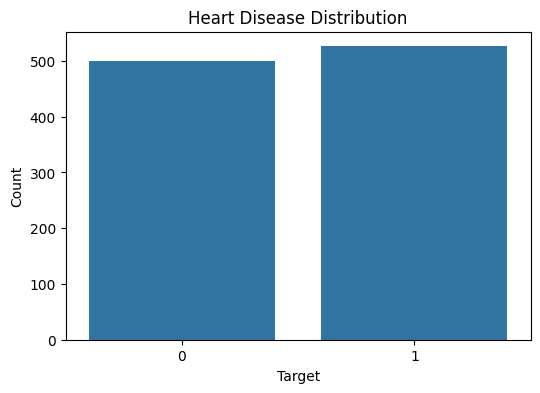

In [7]:
plt.figure(figsize = (6,4))

sns.countplot(x = 'target', data = df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

**Interpretation**

- 0 = No Heart Disease
- 1 = Heart Disease

# **Step 5 : Correlation Heatmap**

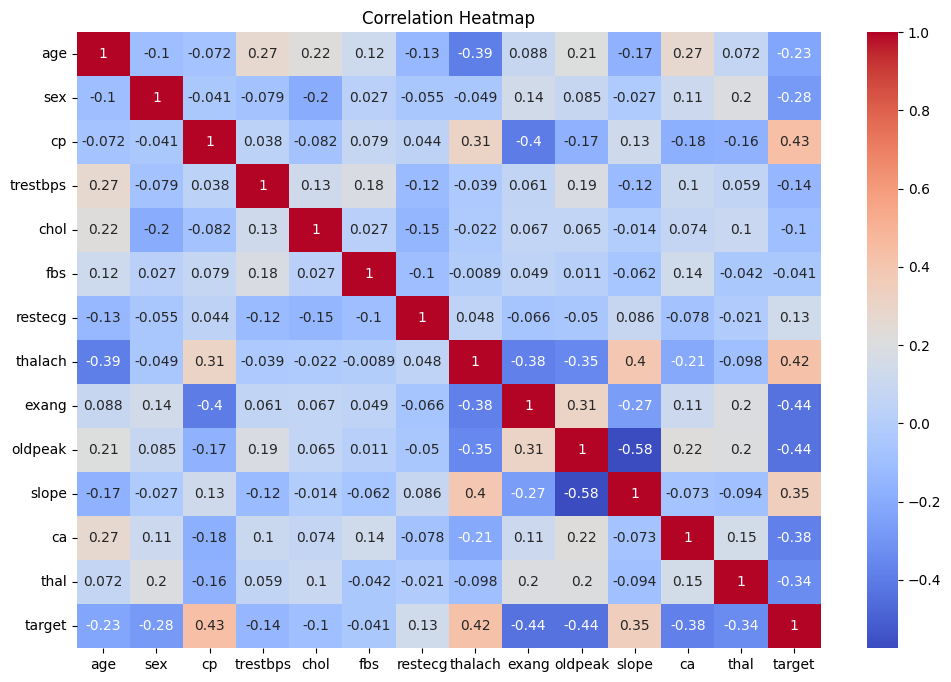

In [8]:
plt.figure(figsize = (12,8))

sns.heatmap(
    df.corr(),
    annot = True,
    cmap = 'coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**Purpose**

Helps identify highly correlated features.

# **Step 6 : Separate Features and Target**

In [11]:
X = df.drop('target', axis = 1)
y = df['target']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1025, 13)
Target Shape : (1025,)


# **Step 7 : Train Test Split**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (820, 13)
Testing Data : (205, 13)


# **Step 8 : Feature Scaling**

**IMP**

ANN performs best on scaled data.

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train[:5])

[[-5.85840222e-01  6.54653671e-01  1.00827500e+00 -7.79453566e-01
  -1.93503098e+00 -4.14039336e-01 -9.83741901e-01 -1.01909426e+00
  -7.25948939e-01 -2.10661213e-01  1.00526437e+00  2.17169136e+00
  -5.45193165e-01]
 [ 1.05147737e+00 -1.52752523e+00 -9.16720340e-01  2.74173173e+00
   1.61063407e+00 -4.14039336e-01  9.09845796e-01  2.02882145e-01
   1.37750735e+00 -9.12152360e-01  1.00526437e+00 -7.25467395e-01
  -5.45193165e-01]
 [-4.00676907e-02 -1.52752523e+00  1.00827500e+00 -1.34738668e+00
   4.42176271e-01 -4.14039336e-01 -9.83741901e-01  7.70228333e-01
  -7.25948939e-01 -9.12152360e-01  1.00526437e+00 -7.25467395e-01
  -5.45193165e-01]
 [ 5.05704840e-01  6.54653671e-01 -9.16720340e-01  1.86032724e-01
  -2.22635925e-01 -4.14039336e-01  9.09845796e-01  5.08376246e-01
  -7.25948939e-01 -4.73720393e-01 -6.40078509e-01 -7.25467395e-01
   1.11057867e+00]
 [-3.67531209e-01  6.54653671e-01  1.00827500e+00 -3.81900388e-01
  -1.03185928e-03  2.41522946e+00 -9.83741901e-01  7.26586318e-01


# **Step 9 : Build ANN Model**

**ANN Architecture**

```
Input Layer (13 Neurons)
        ↓
Hidden Layer 1 (64)
        ↓
Dropout
        ↓
Hidden Layer 2 (32)
        ↓
Dropout
        ↓
Output Layer (1)
```



In [19]:
ann = Sequential()

# Hidden Layer 1
ann.add(Dense(
    units = 64,
    activation = 'relu',
    input_dim = X_train.shape[1]
))
ann.add(Dropout(0.2))

# Hidden Layer 2
ann.add(Dense(
    units = 32,
    activation = 'relu',
))
ann.add(Dropout(0.2))

# Output Layer
ann.add(Dense(
    units = 1,
    activation = 'sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Step 10 : Compile Model**

**IMP**

In [20]:
ann.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

ann.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

# **Step 11 : Train ANN Model**

In [21]:
history = ann.fit(
    X_train,
    y_train,
    validation_split = 0.20,
    epochs = 100,
    batch_size = 32,
    verbose = 1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.6570 - loss: 0.6218 - val_accuracy: 0.7561 - val_loss: 0.5644
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7851 - loss: 0.4791 - val_accuracy: 0.7500 - val_loss: 0.4880
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8384 - loss: 0.4057 - val_accuracy: 0.7988 - val_loss: 0.4498
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8445 - loss: 0.3593 - val_accuracy: 0.7866 - val_loss: 0.4313
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8735 - loss: 0.3330 - val_accuracy: 0.7927 - val_loss: 0.4162
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.3156 - val_accuracy: 0.7927 - val_loss: 0.4140
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8841 - loss: 0.2869 - val_accuracy: 0.8110 - val_loss: 0.4139
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8963 - loss: 0.2842 - val_accuracy: 0.7988 -

# **Step 12 : Learning Curve Graph**

**IMP**

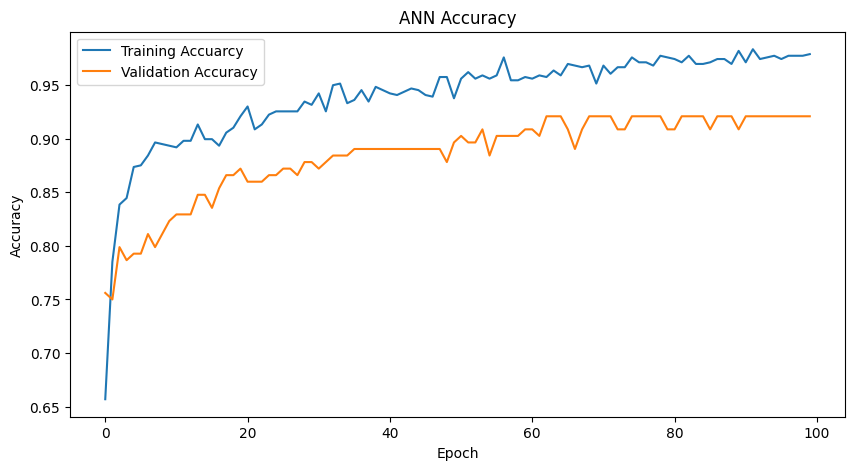

In [22]:
plt.figure(figsize = (10,5))

plt.plot(history.history['accuracy'],
         label = 'Training Accuarcy')

plt.plot(history.history['val_accuracy'],
         label = 'Validation Accuracy')

plt.title("ANN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# **Step 13 : Loss Graph**

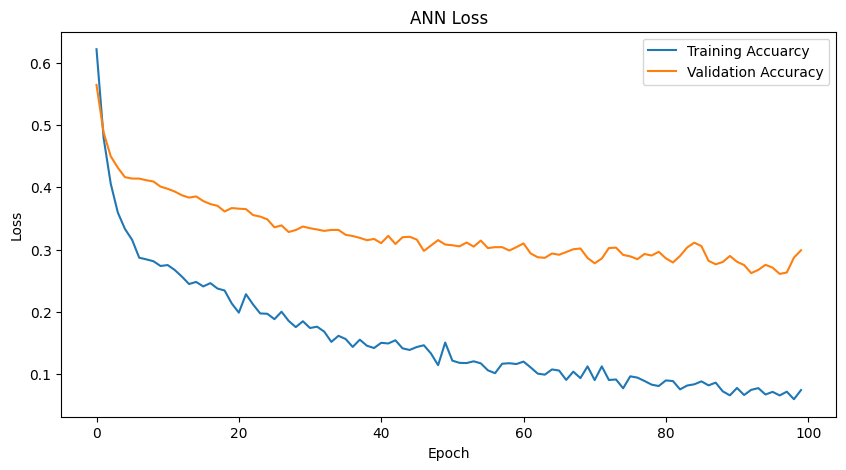

In [23]:
plt.figure(figsize = (10,5))

plt.plot(history.history['loss'],
         label = 'Training Accuarcy')

plt.plot(history.history['val_loss'],
         label = 'Validation Accuracy')

plt.title("ANN Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

## **Step 14 : Predictions**

In [24]:
y_pred_prob = ann.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

print(y_pred[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
[[1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]]


# **Step 15 : Accuracy Score**

In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), '%')

Accuracy : 94.63 %


# **Step 16 : Confusion Matrix**

**IMP**

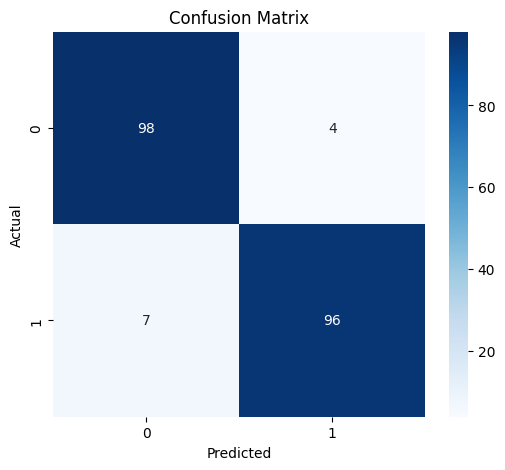

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,5))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **Step 17 : Classification Report**

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       102
           1       0.96      0.93      0.95       103

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



**Gives**

- Precision
- Recall
- F1-Score
- Support

# **Step 18 : ROC Curve**

**IMP Interview Question**

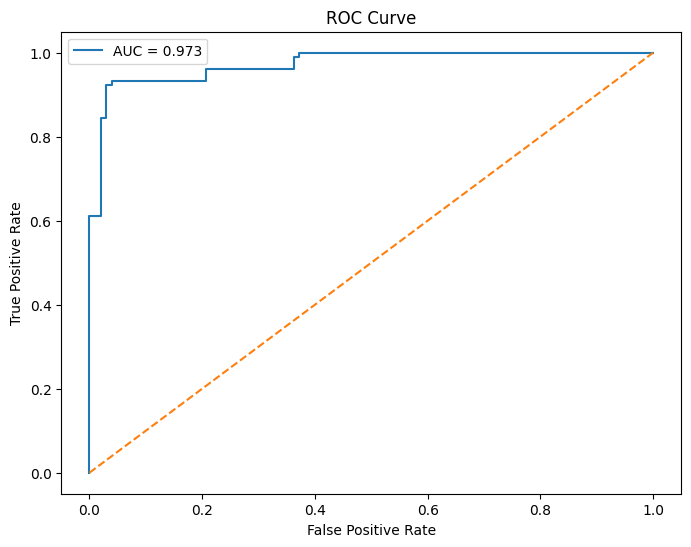

In [28]:
fpr, tpr, threshold = roc_curve(
    y_test,
    y_pred_prob
)

auc_score = roc_auc_score(
    y_test,
    y_pred_prob
)

plt.figure(figsize = (8,6))

plt.plot(fpr, tpr, label = f"AUC = {auc_score:.3f}")

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# **Step 19 : Predict New Patient**

In [29]:
new_patient = [[
    55,   # age
    1,    # sex
    2,    # cp
    130,  # trestbps
    250,  # chol
    0,    # fbs
    1,    # restecg
    150,  # thalach
    0,    # exang
    1.2,  # oldpeak
    2,    # slope
    0,    # ca
    2     # thal
]]

new_patient = scaler.transform(new_patient)

prediction = ann.predict(new_patient)

print(prediction)

if prediction > 0.5:
  print("Heart Diseace Detected")

else:
  print("No Heart Disease")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
[[0.71210164]]
Heart Diseace Detected
